##### ***哈希表***
###### 上一章讲完线性数据结构后，接下来学习非线性结构。<br>哈希表（Hash Table），也叫散列表，是一种极其高效的数据结构。哈希表能在平均情况下，以接近 O(1) 的时间复杂度进行数据的插入、删除和查找，这比数组的遍历（O(n)）和二叉搜索树的搜索（O(log n)）要快得多。
<font size=3>

| 操作 | 数组/链表 | 哈希表 |
| :---: | :---: | :---: |
| 查找 | O(n) | O(1) |
| 插入 | O(n) | O(1) |
| 删除 | O(n) | O(1) |
| 空间效率 | 高 | 中等 |</font>
###### 具体来说，哈希表像是一本字典，只需要提供要查找的汉字的读音即可快速找到所需的汉字。所以哈希表的关键就在于这个“读音”也就是键（key）。
###### 所以正式来说：哈希表是一种通过键（Key）来直接访问值（Value）的数据结构，它利用一个叫做哈希函数的魔法公式，把任意大小的键（比如一个字符串、一个数字或一个对象）转换成一个固定大小的数字，这个数字被称为哈希值或哈希码。然后，用这个哈希值作为数组的索引，将值存储在这个索引对应的数组位置上。这个过程就像给每个键分配一个唯一的座位号（哈希值），然后告诉它：你的数据就放在这个号码的座位上。当你想找这个数据时，只需要用同样的规则再算一次座位号，就能直接走过去拿到它，而不用一个个座位去问。
###### **核心组件**:<br>一个哈希表主要由以下三个核心部分组成：<br>1. 键（Key）： 你要存储和查找数据时使用的标识符。比如，在电话簿中，人名就是键。<br>2. 值（Value）： 与键相关联的实际数据。在电话簿中，电话号码就是值。<br>3. 哈希函数（Hash Function）： 将键映射到数组索引的数学函数。它是哈希表的心脏。
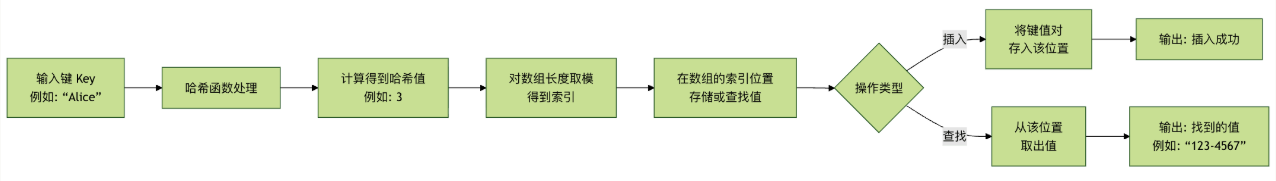
##### ***哈希函数与哈希冲突***
###### 自然而然的一个问题是如何将key转换为哈希值，这里引入一个特殊的函数：**哈希函数**。简单来说哈希函数就是将key转变为一个特殊的输出，而这个哈希函数需要满足如下特性：
<font size=3>

| 特性 | 描述 | 重要性 |
| :---: | :---: | :---: |
| 确定性 | 相同输入总是产生相同输出| 	⭐⭐⭐⭐⭐ |
| 均匀分布 | 	输出均匀分布在哈希表范围内 | 	⭐⭐⭐⭐⭐ |
| 高效计算 | 	计算过程简单快速 | 	⭐⭐⭐⭐ |
| 雪崩效应 | 	输入微小变化导致输出巨大变化 | ⭐⭐⭐ |</font>
###### 常见的哈希函数由于key的类型不同，分为不同的处理方式：
<font size=3>

| 类型 | 示例 | 使用场景 |
| :---: | :---: | :---: |
| 除法取余法 | 	hash = key % table_size| 整数键 |
| 乘法取整法 | 		hash = floor(key * A % 1 * table_size)	 | 	浮点数键 |
| 数字分析法 | 	分析数字的分布规律 | 特定模式数据 |
| 平方取中法 | 	hash = (key * key) // 10^(n/2) % table_size | 	数字键 |
| 字符串哈希 | 逐字符处理 | 字符串键 |</font>
###### 与此同时，一个必须考虑的问题是，随着输入空间的增大，对应的输出空间也会不断变大，而输入空间是无限的，可能有无数个key，但输出空间是有限的，因为计算机能表示的数值有一定范围，所以在key不断增加后必然会出现的一个问题就是不同的key会产生相同的输出，而设计不好的哈希函数会加剧这个现象，我们称之为哈希冲突。除此之外，由于生成的哈希值一般是比较大的数值，而实际的存储空间并没有那么大所以在将哈希值变为具体的索引时需要进行一些特殊操作（如取模）而取模后的数值可能会产生重复，也会导致哈希冲突。于是一个自然的问题是：**如何解决哈希冲突**
###### 两个主流的方法是：**链地址法**和**开放寻址法**。简单来说前者利用链表的机制，将重复的key接到同一个索引，使用指针连接；后者则将重复的key放到其他空位置上。一个好的哈希函数能将输出尽量的均匀分布，不至于让哈希表退化为一个链表。

In [3]:
# 利用Python实现哈希函数
"""假设我们的键是字符串，数组长度是10。一个简单的哈希函数可以是将字符串中每个字符的 ASCII 码相加，然后对数组长度取余数。"""
def simple_hash(key, array_size):
    """
    一个简单的字符串哈希函数。
    :param key: 输入的键（字符串）
    :param array_size: 哈希表数组的大小
    :return: 计算得到的数组索引
    """
    total = 0
    for char in key:
        # 将字符转换为其 ASCII 码值并累加
        total += ord(char)
    # 对数组大小取模，确保索引在数组范围内
    return total % array_size

# 测试我们的哈希函数
keys_to_test = ["Alice", "Bob", "Charlie", "David"]
array_size = 10

print("简单哈希函数测试结果：")
for key in keys_to_test:
    hash_index = simple_hash(key, array_size)
    print(f"  键 '{key}' -> 哈希索引: {hash_index}")

简单哈希函数测试结果：
  键 'Alice' -> 哈希索引: 8
  键 'Bob' -> 哈希索引: 5
  键 'Charlie' -> 哈希索引: 6
  键 'David' -> 哈希索引: 8


###### 上述的哈希函数显而易见的出现了哈希冲突（不同的key有相同的索引），所以接下来讲解两种常见的解决方法：**链地址法**和**开放地址法**。

In [5]:
# 1、链地址法
class HashTableChaining:
    # 使用链地址法构造的哈希表
    def __init__(self, size=10):
        # 初始化哈希表
        self.size = size 
        # 创建一个大小为size的列表，然后将每个元素初始化为空列表用于后续的链接操作
        self.table = [[] for _ in range(size)]

    def _hash(self, key):
        # 利用Python内部的hash函数并取模
        return hash(key) % self.size 

    def insert(self, key, value):
        # 向哈希表中插入一个键值对
        index = self._hash(key)
        bucket = self.table[index] # 获取索引所在的列表

        # 遍历bucket检查键是否已经存在
        for i, (k, v) in enumerate(bucket):
            if k == key: # 如果键存在，说明是修改操作，需要更新
                bucket[i] = (key, value)
                return 
        # 否则是添加操作，将新键值对添加到链表末尾
        bucket.append((key, value))

    def get(self, key):
        # 通过键获取值
        index = self._hash(key)
        bucket = self.table[index]
        for k, v in bucket:
            if k == key:
                return v
        return None

    def delete(self, key):
        # 根据键删除键值对
        index = self._hash(key)
        bucket = self.table[index]
        for i, (k, v) in enumerate(bucket):
            if k == key:
                del bucket[i]
                return True
        return False

    def display(self):
        for i, bucket in enumerate(self.table):
            print(f"索引{i}:{bucket}")

# 使用示例
print("\n--- 链地址法哈希表示例 ---")
phone_book = HashTableChaining(5)
phone_book.insert("Alice", "123-4567")
phone_book.insert("Bob", "987-6543")
phone_book.insert("Charlie", "555-1234")
# 假设"David"的哈希值与"Alice"冲突（为了演示）
phone_book.insert("David", "111-2222")

print("插入数据后的哈希表：")
phone_book.display()

print(f"\n查找 'Bob' 的电话: {phone_book.get('Bob')}")
print(f"查找不存在的 'Eve': {phone_book.get('Eve')}")

phone_book.delete("Charlie")
print("\n删除 'Charlie' 后的哈希表：")
phone_book.display()


--- 链地址法哈希表示例 ---
插入数据后的哈希表：
索引0:[]
索引1:[('Alice', '123-4567')]
索引2:[('Bob', '987-6543')]
索引3:[('David', '111-2222')]
索引4:[('Charlie', '555-1234')]

查找 'Bob' 的电话: 987-6543
查找不存在的 'Eve': None

删除 'Charlie' 后的哈希表：
索引0:[]
索引1:[('Alice', '123-4567')]
索引2:[('Bob', '987-6543')]
索引3:[('David', '111-2222')]
索引4:[]


In [10]:
# 开放地址法：当发生冲突时通过某种探测算法寻找空位插入
"""
常见的方法有：
1. 线性探测：如果位置 i 被占，则尝试 i+1, i+2, i+3... 直到找到空位。
2. 二次探次：如果位置 i 被占，则尝试 i+1^2, i+2^2, i+3^2...。
3. 双重哈希：使用第二个哈希函数来计算探测的步长。
"""
class HashTableLinearProbing:
    def __init__(self, size=10):
        self.size = size
        # 使用一个特殊标记 `None` 表示空位，使用一个标记（如 `'DELETED'`）表示已删除的位置
        # 为了简化，这里只用 `None` 表示空位，查找时遇到 `None` 就停止
        self.keys = [None] * size
        self.values = [None] * size

    def _hash(self, key):
        return hash(key) % self.size

    def insert(self, key, value):
        index = self._hash(key)
        original_index = index

        # 线性探测寻找空位或者相同的键
        while self.keys[index] is not None:
            if self.keys[index] == key:
                # 如果键存在，则更新
                self.values[index] = value
                return 
            index = (index + 1) % self.size # 如果位置不是空且键不存在，则移动到下一个
            if index == original_index:
                # 如果找了一圈都没空位，则表满了
                raise Exception("哈希表已满")

        # 找到空位，插入
        self.keys[index] = key
        self.values[index] = value

    def get(self, key):
        index = self._hash(key)
        original_index = index

        while self.keys[index] is not None:
            if self.keys[index] == key:
                return self.values[index]
            index = (index + 1) % self.size
            if index == original_index:
                break
        return None

    def display(self):
        for i in range(self.size):
            if self.keys[i] is not None:
                print(f"索引 {i}: 键={self.keys[i]}, 值={self.values[i]}")
            else:
                print(f"索引 {i}: 空")

# 使用示例
print("\n--- 线性探测哈希表示例 ---")
ht_linear = HashTableLinearProbing(7) # 用小尺寸容易看到探测
ht_linear.insert("Apple", 10)
ht_linear.insert("Banana", 20)
ht_linear.insert("Cherry", 30)
# 假设"Date"和"Apple"哈希冲突
ht_linear.insert("Date", 40)

print("插入数据后的哈希表：")
ht_linear.display()

print(f"\n查找 'Banana': {ht_linear.get('Banana')}")
print(f"查找 'Date' (冲突后插入的): {ht_linear.get('Date')}")


--- 线性探测哈希表示例 ---
插入数据后的哈希表：
索引 0: 键=Cherry, 值=30
索引 1: 键=Date, 值=40
索引 2: 空
索引 3: 空
索引 4: 键=Apple, 值=10
索引 5: 键=Banana, 值=20
索引 6: 空

查找 'Banana': 20
查找 'Date' (冲突后插入的): 40


###### 两种方法的对比：
<font size=2>

| 特性 | 链地址法 | 开放地址法 |
| :---: | :---: | :---: |
| **实现难度** | 相对简单| 	相对复杂，尤其是删除操作 |
| **空间开销** | 	需要额外空间存储指针（链表） | 	所有数据都在数组中，空间利用率可能更高 |
| **冲突影响** | 	冲突只影响同一个桶（链表）的性能 | 	冲突会影响后续插入的位置，可能导致"聚集"现象 |
| **扩容时机** | 	当平均链表长度超过阈值时扩容 | 当负载因子（元素数/数组大小）超过阈值时扩容 |
| **适用场景** | 通用，更常见 | 对缓存友好，适用于已知最大数据量或内存紧张的场景 |</font>

##### 此外，哈希表的性能高度依赖于一个关键指标：负载因子。所谓负载因子指的是：哈希表中已存储的元素数量/哈希表数组的总大小，如果负载因子较低则说明哈希表中还有很多空位冲突概率小，操作速度快，反之则表示哈希表快满，性能下降。而当负载因子超过某个阈值时（如0.75），哈希表会进行扩容操作：<br>1. 创建一个新的、更大的数组（通常是原大小的两倍）。<br>2. 遍历旧哈希表中的所有键值对。<br>3. 根据新的数组大小，用哈希函数重新计算每个键的索引，并将其插入到新数组中。<br>这个过程称为Rehasing，虽然耗时，但是能显著降低负载因子，使哈希表恢复高效。

In [11]:
# 实践练习：构建一个单词计数器统计一段文本中每个单词出现的次数。
# 练习：使用我们实现的 HashTableChaining 来统计词频
print("\n=== 实践练习：单词计数器 ===")

# 1. 创建哈希表
word_counter = HashTableChaining(size=10)

# 2. 提供的文本
text = "the quick brown fox jumps over the lazy dog the dog is not lazy at all"
words = text.split() # 将句子切割成单词
print("处理的单词列表:", words)


=== 实践练习：单词计数器 ===
处理的单词列表: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'the', 'dog', 'is', 'not', 'lazy', 'at', 'all']


In [12]:
# 3. 遍历单词插入哈希表
for word in words:
    current_count = word_counter.get(word)
    if current_count is None:
        # 说明此时哈希表里的这个单词是第一次出现，current_count还没有计数，所以要添加这个单词，并添加计数
        word_counter.insert(word, 1)
    else:
        # 其他情况说明当前单词再次出现，所以计数要加一
        word_counter.insert(word, current_count + 1)

# 4. 输出统计结果
print("\n单词出现次数统计：")
all_entries = []
for bucket in word_counter.table:
    all_entries.extend(bucket) # 将所有桶中的条目合并

for word, count in all_entries:
    print(f"  '{word}': {count} 次")

# 5. 验证特定单词
test_word = "the"
print(f"\n验证：单词 '{test_word}' 出现了 {word_counter.get(test_word)} 次。")
test_word = "lazy"
print(f"验证：单词 '{test_word}' 出现了 {word_counter.get(test_word)} 次。")



单词出现次数统计：
  'quick': 1 次
  'not': 1 次
  'at': 1 次
  'dog': 2 次
  'over': 1 次
  'all': 1 次
  'fox': 1 次
  'is': 1 次
  'jumps': 1 次
  'brown': 1 次
  'lazy': 2 次
  'the': 3 次

验证：单词 'the' 出现了 3 次。
验证：单词 'lazy' 出现了 2 次。
